# Explore a bit more in depth the MLRSNet data

Specifically & importantly **whether it is fit for our purpose**


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [84]:
import os, sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps

from PIL import Image
from torchvision import datasets, transforms
from torchvision.utils import save_image

In [123]:
tr_pipe = transforms.Compose([transforms.Resize((64,64)),transforms.ToTensor()])

def load_im( path):
    return Image.open( path).convert( 'RGB')

def to_numpy( image_tensor):
    return np.swapaxes( np.swapaxes( np.asarray( image_tensor), 0, 1), 1, 2)

def side_by_side( image, title= None):
    image_tr = tr_pipe( image)
    f, ax = plt.subplots( ncols=2)
    ax[0].imshow( image)
    ax[1].imshow( to_numpy( image_tr))
    ax[0].set_axis_off()
    ax[1].set_axis_off()
    if title is not None:
        if type(title)==list:
            ax[0].set_title( title[0])
            ax[1].set_title( title[1])
        else:
            ax[0].set_title( title)
            ax[1].set_title( 'Downsampled')

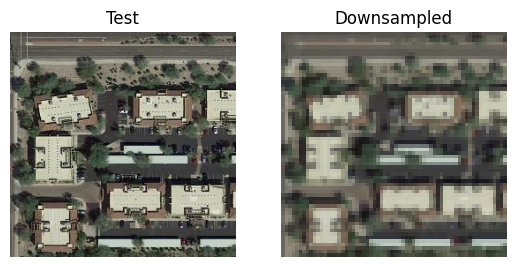

In [124]:
side_by_side( load_im('../data/MLRSNet-subset/dense_residential_area_00001.jpg'), title= 'Test')

In [80]:
images_path = '../data/MLRSNet/'
labels_path = '../../MLRSNet-master/labels/'
label_files = [x for x in os.listdir( labels_path) if x.endswith('.csv')]

In [94]:
df = None
dfg = None
for file in label_files:
    df_ = pd.read_csv( f'{labels_path}{file}')
    df_['B_R_C'] = df_.apply( lambda x: f'{x.buildings}{x.road}{x.cars}', axis= 1)
    df = pd.concat([df,df_])
    try:
        dfg = dfg.merge(
            df_.groupby('B_R_C').count()[['image']].rename(columns={'image':file.replace('.csv','')}),
            left_index= True, right_index= True, how= 'outer'
        )
    except AttributeError:
        print(file)
        dfg = df_.groupby('B_R_C').count()[['image']].rename(columns={'image':file.replace('.csv','')})
df['category'] = df['image'].apply( lambda x: '_'.join( x.split('_')[:-1]))

airplane.csv


<Axes: ylabel='B_R_C'>

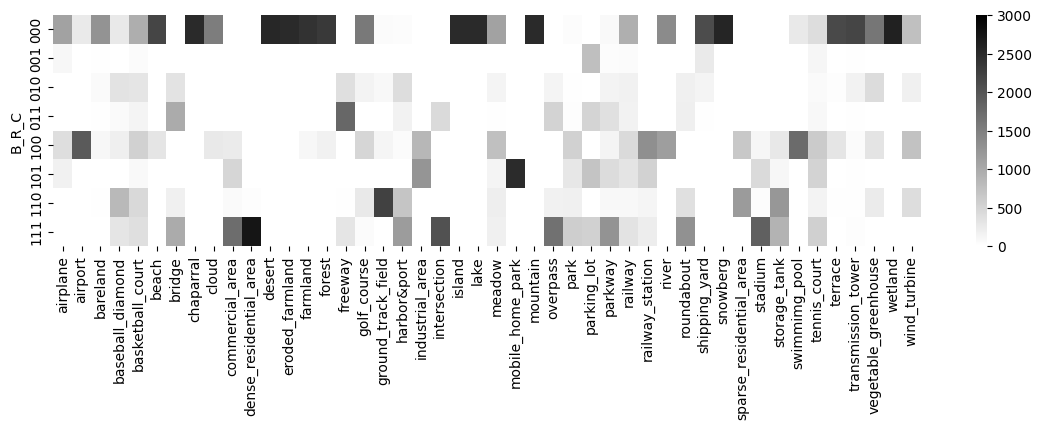

In [96]:
_, ax = plt.subplots( figsize= (14,3))
sns.heatmap(dfg, cmap=colormaps['grey'].reversed(),vmin=0,vmax=3000)

In [152]:
len(df), len(dfg.T)

(109161, 46)

In [153]:
df.columns

Index(['image', 'airplane', 'airport', 'bare soil', 'baseball diamond',
       'basketball court', 'beach', 'bridge', 'buildings', 'cars', 'chaparral',
       'cloud', 'containers', 'crosswalk', 'dense residential area', 'desert',
       'dock', 'factory', 'field', 'football field', 'forest', 'freeway',
       'golf course', 'grass', 'greenhouse', 'gully', 'habor', 'intersection',
       'island', 'lake', 'mobile home', 'mountain', 'overpass', 'park',
       'parking lot', 'parkway', 'pavement', 'railway', 'railway station',
       'river', 'road', 'roundabout', 'runway', 'sand', 'sea', 'ships', 'snow',
       'snowberg', 'sparse residential area', 'stadium', 'swimming pool',
       'tanks', 'tennis court', 'terrace', 'track', 'trail',
       'transmission tower', 'trees', 'water', 'wetland', 'wind turbine',
       'B_R_C', 'category'],
      dtype='object')

In [134]:
df.groupby('category').agg({'buildings':'sum','road':'sum','cars':'sum'}).head(3)

,buildings,road,cars
category,,,
airplane,560,0,268
airport,1939,0,0
bareland,132,97,42


In [79]:
ims_with_cars = df.loc[df['cars']==1,'image'].tolist()

In [113]:
selected = [x for x in ims_with_cars if x.startswith('meadow')]

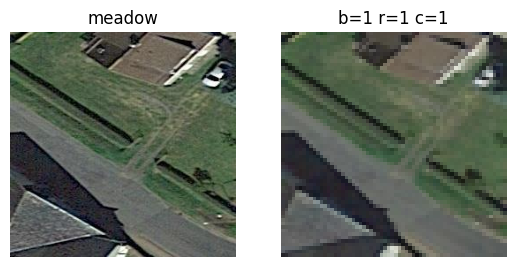

In [149]:
which = 2
fname = selected[ which]
im_fpath = f'{images_path}{fname}'
cat, annot = df.loc[
    df.image==fname, ['category','B_R_C']
].values.reshape(-1).tolist()
annot_str = ' '.join([f'{x}={y}' for x, y in zip('brc',annot)])
side_by_side( load_im( im_fpath), [cat, annot_str])

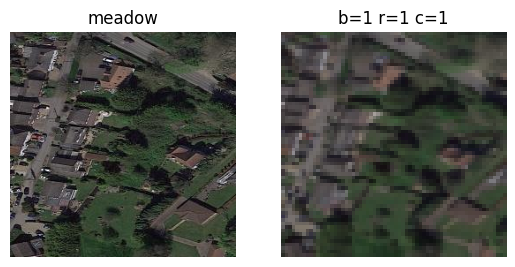

In [148]:
which = 3
fname = selected[ which]
im_fpath = f'{images_path}{fname}'
cat, annot = df.loc[
    df.image==fname, ['category','B_R_C']
].values.reshape(-1).tolist()
annot_str = ' '.join([f'{x}={y}' for x, y in zip('brc',annot)])
side_by_side( load_im( im_fpath), [cat, annot_str])

In [139]:
df.loc[df.image==selected[which],['category','B_R_C']].values.reshape(-1).tolist()

['meadow', '111']

In [144]:
' '.join([f'{x}={y}' for x, y in zip('brc','111')])

'b=1 r=1 c=1'

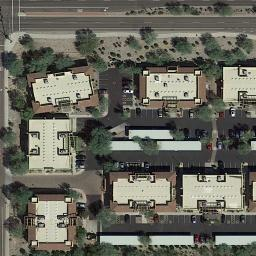

In [154]:
im